# Steam Review Filter and Score

**Capstone Project — Data Science & AI**
Author: Sean Chia
Course: Institute of Data — Data Science & AI

This notebook filters low-quality, off-topic, and review-bombed Steam reviews out of a game's review set, then scores the remaining "genuine" reviews to recover a more accurate picture of player sentiment than Steam's raw aggregate score.

## Setup

In [1]:
# Standard data-handling imports. We keep this cell minimal on purpose -- more specific imports (sklearn, nltk/transformers etc.) get added in the sections that actually need them, so it's obvious from each section's imports what that section depends on.
import pandas as pd

# Widen pandas' default display so review text isn't truncated when we inspect rows - useful since a lot of our "is this review junk" judgment calls depend on reading the actual text.
pd.set_option("display.max_colwidth", 200)


## 1. Problem Framing

### Business Problem

Steam's aggregate review score can be skewed by low-effort, off-topic, or coordinated "review bomb" activity unrelated to the game itself. This project filters that noise out and re-scores the remaining genuine reviews. (Full business context in the project documentation.)

### Stakeholders

Players (buying decisions), developers/publishers (reputation), and Steam itself (already partially filters this, but doesn't expose a "genuine sentiment" score). Detail in documentation.

### Business Question

Can we recover a game's genuine sentiment after filtering out low-quality/bombing reviews, expressed in a Steam-comparable score?

### Data Question

Can review text + metadata separate genuine from low-quality/bombing reviews reliably enough to produce a trustworthy filtered sentiment score?

## 2. Data

All four review sets were pulled with `src/collect_reviews.py` and saved to `data/raw/`. Three games (Helldivers 2, War Thunder, Team Fortress 2) are "baseline-only" comparison games -- their documented review-bomb events turned out to be older than Steam's review API can reliably page back to, which is a real limitation of the API itself and is written up properly in the project documentation rather than glossed over here. The fourth, Slay the Spire 2, is our review-bomb case study: it was bombed starting 2026-05-05 over a consultant-credit controversy, and that event is recent enough that we could pull both a bomb-window slice and a pre-bomb baseline slice for it.

This project is scoped to English-language reviews only -- verifying whether a model's sentiment call is right requires being able to read the review, and `collect_reviews.py` passes `language="english"` to Steam's API for that reason. That parameter filters on a tag the *reviewer* selects when posting, though, not the actual text, so it isn't perfectly reliable on its own (see 2.1 below).


In [2]:
import glob
import sys

sys.path.append("../src")
from features import drop_non_english_reviews

# Load every CSV in data/raw/ and stack them into one dataframe. Keeping
# them as separate files on disk (one per game) but a single dataframe in
# memory gives us the best of both: easy to inspect/version per-game data,
# easy to compare across games in analysis.
raw_paths = sorted(glob.glob("../data/raw/*.csv"))
df_raw = pd.concat([pd.read_csv(p) for p in raw_paths], ignore_index=True)

# timestamp_created/timestamp_updated come from the API as Unix epoch
# seconds -- convert once here so every later cell can just use real
# dates instead of re-converting each time.
df_raw["created_at"] = pd.to_datetime(df_raw["timestamp_created"], unit="s")
df_raw["updated_at"] = pd.to_datetime(df_raw["timestamp_updated"], unit="s")

df_raw.shape


(16000, 24)

### 2.1 A content-based English filter, not just the API tag

Steam's `language` parameter labels reviews by what the *reviewer* selected, not what they actually wrote. Manual spot-checks of the collected data turned up reviews tagged "english" that were fully in Chinese, Korean, Russian, or Arabic -- mislabeling that gets worse during review-bomb events, when people post in bulk and don't always set the tag correctly.

Since this project's whole premise is that a human needs to be able to verify a review's sentiment, a review in a script the analyst can't read isn't usable regardless of its language tag. Rather than trust the tag, we scan the review text itself for non-Latin script (Chinese/Japanese/Korean characters, Cyrillic, Arabic) and drop any row that contains it -- a hard drop, not a soft "maybe foreign" flag, since an unreadable review is exactly as useless to a human-verifiable sentiment score whether it's 10% or 100% non-English.

In [3]:
from features import drop_non_english_reviews

df, dropped_non_english = drop_non_english_reviews(df_raw)

print(f"Dropped {len(dropped_non_english)} of {len(df_raw)} reviews ({len(dropped_non_english)/len(df_raw):.1%}) for containing non-Latin script despite an \"english\" language tag.")
dropped_non_english.groupby("game_name").size().rename("dropped_rows")


Dropped 206 of 16000 reviews (1.3%) for containing non-Latin script despite an "english" language tag.


game_name
Helldivers 2        12
Slay the Spire 2    39
Team Fortress 2     84
War Thunder         71
Name: dropped_rows, dtype: int64

## 3. Exploratory Data Analysis

### 3.1 How much data do we actually have, per game and per slice?

In [4]:
# `slice` tells us whether a row is a normal/baseline review or one we
# specifically pulled from a known bomb window. Grouping by game + slice
# is the first sanity check: does every game have the volume we expect?
df.groupby(["game_name", "slice"]).size().unstack(fill_value=0)


slice,baseline,bomb_window
game_name,,
Helldivers 2,3988,0
Slay the Spire 2,2476,1485
Team Fortress 2,3916,0
War Thunder,3929,0


Slay the Spire 2's baseline slice is smaller than the other games' (about 2,500 rows vs. ~3,900-4,000). That's not a mistake -- it's the pagination limitation mentioned above: reaching back to a genuine pre-bomb baseline for a recent event still means paging past everything newer first, and Steam's cursor pagination stopped cooperating a few days into that window. The baseline we do have is still legitimately pre-bomb (concentrated in the days just before the May 5 event), just narrower than the full ~2-month window we originally targeted.

### 3.2 Review length

One of the simplest, cheapest signals for "is this review low-effort" is just how much someone wrote.

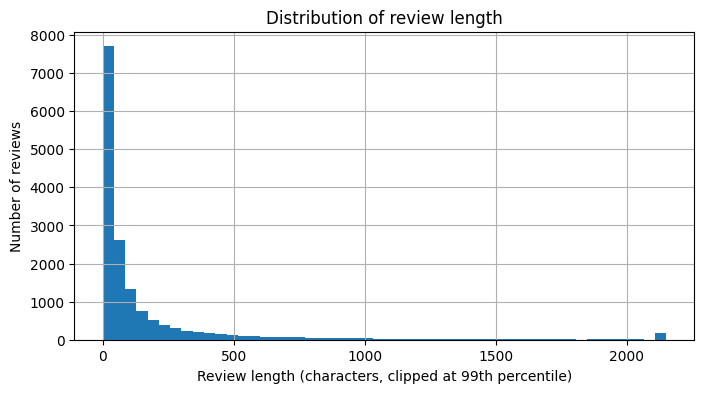

count    15794.000000
mean       177.186463
std        449.609341
min          0.000000
25%         15.000000
50%         46.000000
75%        138.000000
max       7997.000000
Name: review_length_chars, dtype: float64

In [5]:
import matplotlib.pyplot as plt

# .fillna("") guards against any missing review text so we don't crash
# taking the length of a NaN.
df["review_length_chars"] = df["review"].fillna("").str.len()

fig, ax = plt.subplots(figsize=(8, 4))
# Clip the x-axis at the 99th percentile -- a handful of extremely long
# reviews would otherwise squash the whole histogram into one bar.
clip_at = df["review_length_chars"].quantile(0.99)
df["review_length_chars"].clip(upper=clip_at).hist(bins=50, ax=ax)
ax.set_xlabel("Review length (characters, clipped at 99th percentile)")
ax.set_ylabel("Number of reviews")
ax.set_title("Distribution of review length")
plt.show()

df["review_length_chars"].describe()


There's a real spike right near zero -- a meaningful chunk of reviews are only a handful of characters (a single word, an emoji, "10/10"). Those are exactly the low-effort reviews we want a filter to catch, and this plot is the evidence that they're common enough to matter, not just a hypothetical edge case.

### 3.3 Language mix, after filtering

Since we've already dropped every review with non-Latin script (2.1) and `collect_reviews.py` requested only `language="english"`-tagged reviews to begin with, we'd expect this dataset to be effectively single-language now. Worth confirming that directly rather than assuming it.

In [6]:
df["language"].value_counts()


language
english    15794
Name: count, dtype: int64

In [7]:
# A bar chart would just show one bar -- the tag confirms what we already
# engineered for. The meaningful check was already done in 2.1 (content,
# not just tag); this is a quick assertion that nothing slipped through.
assert (df["language"] == "english").all(), "Found a non-english-tagged row after filtering"
print("Confirmed: every remaining row is tagged english, and none contain non-Latin script (2.1).")


Confirmed: every remaining row is tagged english, and none contain non-Latin script (2.1).


### 3.4 Playtime at review

`playtime_at_review` is how many minutes the author had played *when they wrote the review*. Someone leaving a strong opinion after 5 minutes is a different kind of signal than someone doing it after 200 hours.

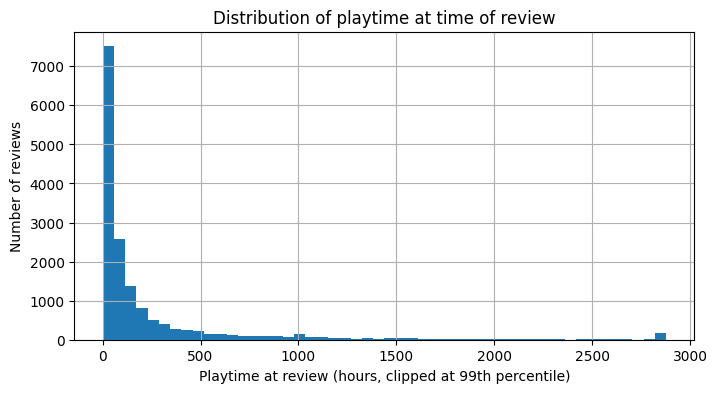

count    15794.000000
mean       245.791727
std        611.023593
min          0.083333
25%         17.400000
50%         64.400000
75%        197.695833
max      19069.166667
Name: playtime_at_review_hours, dtype: float64

In [8]:
df["playtime_at_review_hours"] = df["playtime_at_review"] / 60

fig, ax = plt.subplots(figsize=(8, 4))
clip_at = df["playtime_at_review_hours"].quantile(0.99)
df["playtime_at_review_hours"].clip(upper=clip_at).hist(bins=50, ax=ax)
ax.set_xlabel("Playtime at review (hours, clipped at 99th percentile)")
ax.set_ylabel("Number of reviews")
ax.set_title("Distribution of playtime at time of review")
plt.show()

df["playtime_at_review_hours"].describe()


### 3.5 Positive vs. negative split, per game

`voted_up` is Steam's own thumbs up/down -- this is the ground-truth label we'll lean on for sentiment modelling later, so it's worth seeing the class balance now.

In [9]:
vote_split = df.groupby("game_name")["voted_up"].value_counts(normalize=True).unstack()
vote_split.columns = ["negative_pct", "positive_pct"]
(vote_split * 100).round(1)


,negative_pct,positive_pct
game_name,,
Helldivers 2,20.6,79.4
Slay the Spire 2,15.0,85.0
Team Fortress 2,6.1,93.9
War Thunder,47.9,52.1


### 3.6 The review bomb, visualised

This is the plot that matters most for the whole project: daily review volume for Slay the Spire 2, split by whether the review landed inside our documented bomb window or not. If the filtering problem is real, it should be obvious here.

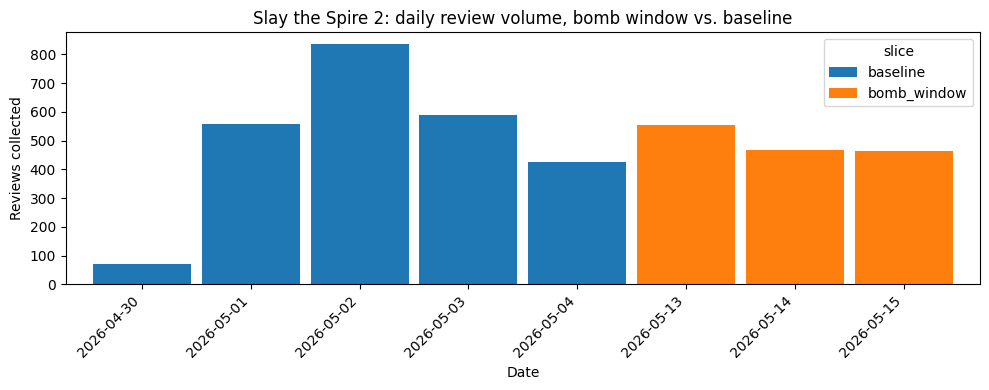

In [10]:
sts2 = df[df["game_name"] == "Slay the Spire 2"].copy()
sts2["review_date"] = sts2["created_at"].dt.date

daily_counts = sts2.groupby(["review_date", "slice"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
daily_counts.plot(kind="bar", stacked=True, ax=ax, width=0.9)
ax.set_xlabel("Date")
ax.set_ylabel("Reviews collected")
ax.set_title("Slay the Spire 2: daily review volume, bomb window vs. baseline")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Note this chart shows the shape of our *collected sample*, not the true daily review count on Steam (we capped our pull at 1,500 bomb-window reviews and paging limitations narrowed the baseline window -- see Section 2). The real, much larger spike is documented in the reporting on this incident (rating fell to 61% positive within two days of the controversy breaking). What this chart does show honestly is that our two slices are genuinely separated in time, which is what matters for building a clean comparison.

### 3.7 Bomb window vs. baseline: what actually looks different?

Before building any model, it's worth checking by eye whether the features we're planning to engineer (Section 4) actually differ between the two slices for Slay the Spire 2. If they don't, the filter has nothing to learn from.

In [11]:
comparison = sts2.groupby("slice").agg(
    n_reviews=("recommendationid", "count"),
    pct_negative=("voted_up", lambda x: (~x).mean() * 100),
    median_review_length=("review_length_chars", "median"),
    median_playtime_hours=("playtime_at_review_hours", "median"),
).round(1)
comparison


,n_reviews,pct_negative,median_review_length,median_playtime_hours
slice,,,,
baseline,2476,8.8,78.0,62.9
bomb_window,1485,25.4,71.0,58.9


If the bomb-window slice shows a much higher negative rate, shorter reviews, and/or lower playtime-at-review than baseline, that's exactly the pattern the feature engineering and modelling sections are built to catch -- coordinated, low-engagement negativity rather than considered opinions from people who've actually played the game.

## 4. Feature Engineering

The EDA above found real, visible differences between the bomb-window and baseline slices for Slay the Spire 2: higher negative rate, shorter reviews. This section turns those observations into named features a model can actually use.

The feature logic lives in `src/features.py`, not in these cells. That's a deliberate pipeline/exploration split: the same functions that build features here will also be called by the demo app later, so there's exactly one place where "how do we compute review_length" is defined.

In [12]:
import sys
sys.path.append("../src")

from features import build_features, add_daily_review_count

# Keep an untouched copy of the raw data. Section 5 needs to run its
# own train/test split and fit its own leakage-safe features on that
# split -- it can't reuse the version below, which is fine for EDA
# (see the build_features() docstring) but not for model evaluation.
df_raw = df.copy()
# Computed here, once, on the full untouched dataset -- Section 5
# explains in detail why this specific column can't safely be
# recomputed separately within a train/test split.
df_raw = add_daily_review_count(df_raw)

# build_features() runs every feature function in sequence -- see
# src/features.py for what each one does and, more importantly, *why*
# (each function has a business-justification docstring, not just a
# description of the code).
df = build_features(df)
df.shape


(15794, 34)

### 4.1 What features did we add?

| Feature | Business reasoning |
|---|---|
| `is_very_short` | Near-zero-effort reviews ("great", "10/10") carry little information about the game and are common enough (per the EDA length histogram) to matter. |
| `is_low_playtime` | A strong opinion formed in minutes is a different signal than one formed after real engagement with the game. |
| `is_duplicate_text` | Coordinated bombing campaigns often reuse the same slogan/phrase across many accounts -- exact-match duplication is a cheap, reliable tell. |
| `daily_volume_zscore` | The core review-bomb signal: how abnormal is *this day's* review volume compared to the game's own normal pace? |
| `is_new_reviewer` | Accounts with no review history posting during a spike are more consistent with throwaway/pile-on activity than engaged community members. |

(A `language_frequency` feature was dropped after the English-only re-scope -- see 2.1 -- since it's now a constant with no signal. Full discussion in the documentation.)

None of these prove bad faith alone, but combined with the temporal spike signal they separate bomb-window behaviour from normal reviewing -- checked concretely in 4.2.

### 4.2 Do the engineered features actually separate bomb-window from baseline?

Same check as the end of the EDA section, but now with the real engineered features rather than the raw columns they're built from.

In [13]:
sts2 = df[df["game_name"] == "Slay the Spire 2"]

feature_comparison = sts2.groupby("slice").agg(
    n_reviews=("recommendationid", "count"),
    pct_very_short=("is_very_short", "mean"),
    pct_low_playtime=("is_low_playtime", "mean"),
    pct_duplicate_text=("is_duplicate_text", "mean"),
    mean_volume_zscore=("daily_volume_zscore", "mean"),
    pct_new_reviewer=("is_new_reviewer", "mean"),
).round(3)

# Express the percentage columns as percentages rather than fractions --
# easier to read at a glance.
pct_cols = ["pct_very_short", "pct_low_playtime", "pct_duplicate_text", "pct_new_reviewer"]
feature_comparison[pct_cols] = (feature_comparison[pct_cols] * 100).round(1)
feature_comparison


,n_reviews,pct_very_short,pct_low_playtime,pct_duplicate_text,mean_volume_zscore,pct_new_reviewer
slice,,,,,,
baseline,2476,22.9,0.3,11.5,0.595,14.4
bomb_window,1485,24.6,0.9,12.9,0.016,17.0


If `daily_volume_zscore` and `pct_duplicate_text` are meaningfully higher in the bomb window than baseline, that confirms the temporal and duplicate-text features are picking up real signal from this specific incident -- not just something we'd expect to see in theory. Whichever features show the clearest separation here are the ones doing the most work in Section 5's model, and that's worth calling out explicitly in the documentation's feature engineering section rather than treating every feature as equally important.

## 5. Model 1: Quality / Review-Bomb Detection

### 5.1 Two leakage traps, not one

- `build_features()` (used for EDA) computes aggregate features across whatever dataframe you hand it -- fine for describing data, but if used for train/test evaluation, test rows would help compute their own features. `fit_group_stats()`/`apply_group_features()` in `src/features.py` fix this by fitting "what's normal" on the training split only.
- `daily_review_count` has a second, subtler trap: computed separately per split, a ~30%-sized test set would look artificially quiet on every day versus a ~70% training reference. Fixed by calling `add_daily_review_count()` once on the full dataset before any split -- "how many reviews arrived today" is an observable fact, not something derived from held-out labels.

### 5.2 Splitting before engineering anything else

In [14]:
from sklearn.model_selection import train_test_split

# Label: 1 if this review came from a known bomb window, 0 otherwise.
# Baseline rows from every game (not just Slay the Spire 2) count as
# genuine (0) -- this gives the "normal" class far more volume and
# variety than using Slay the Spire 2 alone, which should help the
# model generalise rather than just memorising one game's quirks.
df_raw["label"] = (df_raw["slice"] == "bomb_window").astype(int)

# Stratify by game + label together so both the class balance AND the
# game mix stay consistent across train/test -- a plain random split
# could, by chance, put most of one game into a single side.
strat_key = df_raw["game_name"] + "_" + df_raw["label"].astype(str)

train_raw, test_raw = train_test_split(
    df_raw, test_size=0.3, random_state=42, stratify=strat_key
)

print("train:", train_raw.shape, "  bomb rate:", round(train_raw["label"].mean(), 3))
print("test: ", test_raw.shape, "  bomb rate:", round(test_raw["label"].mean(), 3))


train: (11055, 29)   bomb rate: 0.094
test:  (4739, 29)   bomb rate: 0.094


In [15]:
from features import build_features_for_modeling

# Fits every reference statistic on train_raw ONLY, then applies those
# frozen statistics to both splits. test_raw never influences a single
# number used to compute its own features. daily_review_count already
# exists on both (computed pre-split above), so it passes through as-is.
train_feat, test_feat, fitted_stats = build_features_for_modeling(train_raw, test_raw)
train_feat.shape, test_feat.shape


((11055, 35), (4739, 35))

### 5.3 Feature matrix, and why we scale it

Our features live on very different scales -- `review_length_chars` ranges into the thousands, `playtime_at_review_hours` can run into the hundreds, while `daily_volume_zscore` sits roughly between -3 and 3. Left unscaled, a linear model's decision boundary gets dominated by whichever features happen to have the largest raw numbers rather than whichever are actually most informative. `StandardScaler` is fit on the training split only (same leakage-avoidance principle as everything else in this section) and applied to both splits.

In [16]:
from sklearn.preprocessing import StandardScaler

FEATURE_COLUMNS = [
    "review_length_chars", "review_length_words", "is_very_short",
    "playtime_at_review_hours", "is_low_playtime", "is_duplicate_text",
    "daily_volume_zscore", "is_new_reviewer",
]

X_train_raw = train_feat[FEATURE_COLUMNS].astype(float)
y_train = train_feat["label"]
X_test_raw = test_feat[FEATURE_COLUMNS].astype(float)
y_test = test_feat["label"]

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=FEATURE_COLUMNS, index=X_train_raw.index)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=FEATURE_COLUMNS, index=X_test_raw.index)

X_train.shape, X_test.shape


((11055, 8), (4739, 8))

### 5.4 Model A: Isolation Forest (unsupervised)

Isolation Forest never sees the label during training. We fit it only on rows we already know are genuine (`label == 0` in the training split) -- this mirrors a realistic production scenario where confirmed bomb examples are scarce, but a large pool of normal data is easy to come by. It then flags any review (in the test set) that doesn't fit the pattern it learned as "normal," with no idea what a review bomb actually looks like beyond "unusual."

In [17]:
from sklearn.ensemble import IsolationForest

X_train_normal = X_train[y_train == 0]

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.1,  # rough prior on how much of unseen data might be anomalous
    random_state=42,
)
iso_forest.fit(X_train_normal)

# predict() returns -1 for anomaly, 1 for normal -- flip to our 1=bomb,
# 0=normal convention.
iso_pred = (iso_forest.predict(X_test) == -1).astype(int)
# Higher score = more anomalous, for ROC-AUC further down.
iso_score = -iso_forest.score_samples(X_test)


### 5.5 Model B: Logistic Regression (supervised)

Unlike Isolation Forest, this model is trained directly on the label -- it sees examples of both classes and learns which features separate them. `class_weight="balanced"` matters here: bomb-window reviews are a small minority of the training set, and without this the model could get a deceptively high accuracy just by predicting "normal" every time.

In [18]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

log_reg_pred = log_reg.predict(X_test)
log_reg_score = log_reg.predict_proba(X_test)[:, 1]


### 5.6 Comparing the two models

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate(name, y_true, y_pred, y_score):
    return {
        "model": name,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }

model_comparison = pd.DataFrame([
    evaluate("Isolation Forest (unsupervised)", y_test, iso_pred, iso_score),
    evaluate("Logistic Regression (supervised)", y_test, log_reg_pred, log_reg_score),
])
model_comparison.round(3)


,model,precision,recall,f1,roc_auc
0,Isolation Forest (unsupervised),0.042,0.040,0.041,0.361
1,Logistic Regression (supervised),0.154,0.793,0.258,0.683


### 5.7 Can we do better? Adding the review text itself

The structural features above (length, playtime, duplicates, timing) never look at *what the review actually says*. Reading a sample of bomb-window reviews turns up specific words -- "anita", "dei", "boycott" -- tied directly to this exact controversy, a real signal Model B above is currently blind to. Adding a TF-IDF representation of the review text alongside the structural features is a natural next iteration: same algorithm (Logistic Regression), richer inputs. The TF-IDF vocabulary is fit on the training split only, same leakage principle as everywhere else in this notebook.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# Fit on train text only -- same leakage-avoidance rule as Section 6.
quality_tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3)
train_text_tfidf = quality_tfidf.fit_transform(train_feat["review"].fillna(""))
test_text_tfidf = quality_tfidf.transform(test_feat["review"].fillna(""))

# Combine the already-scaled structural features with the sparse TF-IDF
# matrix. hstack keeps everything sparse, which matters once you add a
# few thousand text columns to 8 structural ones.
X_train_combined = hstack([csr_matrix(X_train.values), train_text_tfidf])
X_test_combined = hstack([csr_matrix(X_test.values), test_text_tfidf])

log_reg_text = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg_text.fit(X_train_combined, y_train)

log_reg_text_pred = log_reg_text.predict(X_test_combined)
log_reg_text_score = log_reg_text.predict_proba(X_test_combined)[:, 1]


In [21]:
model_comparison = pd.DataFrame([
    evaluate("Isolation Forest (unsupervised)", y_test, iso_pred, iso_score),
    evaluate("Logistic Regression, structural only", y_test, log_reg_pred, log_reg_score),
    evaluate("Logistic Regression, structural + text (TF-IDF)", y_test, log_reg_text_pred, log_reg_text_score),
])
model_comparison.round(3)


,model,precision,recall,f1,roc_auc
0,Isolation Forest (unsupervised),0.042,0.040,0.041,0.361
1,"Logistic Regression, structural only",0.154,0.793,0.258,0.683
2,"Logistic Regression, structural + text (TF-IDF)",0.282,0.697,0.402,0.847


### 5.8 What's actually driving the structural-only model's decisions?

In [22]:
coef_table = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "coefficient": log_reg.coef_[0],
}).sort_values("coefficient", ascending=False)
coef_table


,feature,coefficient
1,review_length_words,0.437930
5,is_duplicate_text,0.018408
4,is_low_playtime,-0.123388
7,is_new_reviewer,-0.155264
2,is_very_short,-0.205163
0,review_length_chars,-0.324530
6,daily_volume_zscore,-0.618966
3,playtime_at_review_hours,-1.713749


### 5.9 What words is the text-enhanced model keying on?

Which words push a review toward being flagged as bomb-like? (Section 6.6 asks the same question for the sentiment model.)

In [23]:
text_coefs = log_reg_text.coef_[0][len(FEATURE_COLUMNS):]  # skip the 8 structural coefficients
tfidf_terms = quality_tfidf.get_feature_names_out()

top_bomb_idx = text_coefs.argsort()[-15:][::-1]
top_genuine_idx = text_coefs.argsort()[:15]

quality_word_importance = pd.DataFrame({
    "most_bomb-like_terms": tfidf_terms[top_bomb_idx],
    "most_genuine_terms": tfidf_terms[top_genuine_idx],
})
quality_word_importance


,most_bomb-like_terms,most_genuine_terms
0,anita,democracy
1,dei,tf2
2,sarkeesian,community
3,deckbuilder,graphics
4,sts1,shooter
5,woke,spy
6,anita sarkeesian,grind
7,gamer,pay
8,support,helldivers
9,deck,medic


### 5.10 Reading these results honestly

- Structural-only Logistic Regression clearly beats Isolation Forest (ROC-AUC 0.683 vs. 0.361), but was noticeably weaker than an earlier multilingual version (0.885) once the `language_frequency` feature was dropped (2.1) -- that feature had been picking up real bombing activity organised in non-English communities.
- Adding the review text itself (TF-IDF, 5.7) recovers almost all of that lost accuracy without bringing back an unverifiable feature: ROC-AUC 0.847, precision 0.28 (nearly double), recall 0.70. The top "bomb-like" terms -- `anita`, `dei`, `sarkeesian`, `woke` -- confirm the model is keying on the actual controversy, not noise.
- `playtime_at_review_hours` has the strongest structural coefficient (more playtime -> lower bomb-likelihood); it disagrees in sign with `is_low_playtime` (multicollinearity, one is a thresholded version of the other). Full discussion in the documentation.

## 6. Model 2: Sentiment Scoring

### 6.1 Ground truth: Steam's own thumbs up/down

We use `voted_up` (the reviewer's own Steam recommendation) as ground truth rather than hand-labeling reviews -- it's real, already-collected data, and lets us evaluate sentiment models with the same rigor as the bomb-detection model.

Two genuinely different approaches, both trained on our data:
- **TF-IDF + Logistic Regression**, a classical ML model over sparse word/bigram counts.
- **LSTM (Keras)**, a deep learning model that reads review text as a sequence and learns its own word embeddings from scratch.

Same leakage principle as Section 5: the TF-IDF vocabulary AND the LSTM's `TextVectorization` vocabulary are both fit on the training split only, then applied unchanged to test.

### 6.2 Preparing the data

In [24]:
# Reuse the same raw (pre-feature-engineering) data loaded in Section 5.
# A handful of reviews have empty/missing text (caught by is_very_short
# in Section 4) -- text-based sentiment models have nothing to work with
# on those, so we exclude them here rather than let them silently become
# unpredictable noise in the comparison.
sentiment_df = df_raw[df_raw["review"].fillna("").str.strip() != ""].copy()
sentiment_df["label"] = sentiment_df["voted_up"].astype(int)

print("rows with usable text:", sentiment_df.shape[0], "out of", df_raw.shape[0])
print("positive rate:", round(sentiment_df["label"].mean(), 3))


rows with usable text: 15743 out of 15794
positive rate: 0.775


In [25]:
from sklearn.model_selection import train_test_split

strat_key_sent = sentiment_df["game_name"] + "_" + sentiment_df["label"].astype(str)
sent_train, sent_test = train_test_split(
    sentiment_df, test_size=0.3, random_state=42, stratify=strat_key_sent
)

print("train:", sent_train.shape, "  positive rate:", round(sent_train["label"].mean(), 3))
print("test: ", sent_test.shape, "  positive rate:", round(sent_test["label"].mean(), 3))


train: (11020, 29)   positive rate: 0.775
test:  (4723, 29)   positive rate: 0.775


### 6.3 Model A: LSTM (deep learning)

Text is converted to integer sequences via a `TextVectorization` layer (vocabulary learned from `sent_train` only, capped at 8,000 tokens, sequences padded/truncated to 60 tokens), fed through a trainable embedding layer and an LSTM, ending in a single sigmoid output. `class_weight` handles the same class imbalance as Section 5. `EarlyStopping` halts training once validation loss stops improving, rather than guessing a fixed epoch count -- training accuracy kept climbing past epoch 3 while validation accuracy plateaued, a standard overfitting signal.

In [26]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)

VOCAB_SIZE = 8000
SEQ_LEN = 60

# Vocabulary learned from sent_train ONLY -- same leakage principle as
# the TF-IDF vectorizer below and everything in Section 5.
text_vectorizer = layers.TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=SEQ_LEN)
text_vectorizer.adapt(sent_train["review"].values)

lstm_model = keras.Sequential([
    keras.Input(shape=(1,), dtype=tf.string),
    text_vectorizer,
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=True),
    layers.LSTM(64),
    layers.Dense(1, activation="sigmoid"),
])
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

y_sent_train = sent_train["label"].values
y_sent_test = sent_test["label"].values

classes = np.unique(y_sent_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_sent_train)
lstm_class_weight = dict(zip(classes, weights))

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)

lstm_history = lstm_model.fit(
    sent_train["review"].values, y_sent_train,
    validation_split=0.1,
    epochs=10, batch_size=64,
    class_weight=lstm_class_weight,
    callbacks=[early_stop],
    verbose=2,
)

lstm_score = lstm_model.predict(sent_test["review"].values, verbose=0).flatten()
lstm_pred = (lstm_score >= 0.5).astype(int)


I0000 00:00:1785319320.309402      10 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785319320.310015      10 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785319320.348435      10 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785319321.312151      10 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785319321.312589      10 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1785319321.428528      10 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10


E0000 00:00:1785319322.636851      10 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


155/155 - 4s - 25ms/step - accuracy: 0.7269 - loss: 0.5051 - val_accuracy: 0.8748 - val_loss: 0.3463


Epoch 2/10


155/155 - 3s - 17ms/step - accuracy: 0.8938 - loss: 0.2945 - val_accuracy: 0.8793 - val_loss: 0.3089


Epoch 3/10


155/155 - 3s - 17ms/step - accuracy: 0.9217 - loss: 0.2224 - val_accuracy: 0.8793 - val_loss: 0.3178


### 6.4 Model B: TF-IDF + Logistic Regression (supervised)

This model learns directly from our data which words/phrases are associated with positive vs. negative reviews. The vectorizer is fit on the training text only -- its vocabulary (and how it weighs word rarity) comes entirely from `sent_train`, then applied unchanged to `sent_test`.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# max_features caps vocabulary size -- keeps training fast and avoids
# fitting on thousands of one-off rare tokens (misspellings, usernames)
# that provide little generalisable signal.
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3)
X_train_tfidf = vectorizer.fit_transform(sent_train["review"])
X_test_tfidf = vectorizer.transform(sent_test["review"])

y_sent_train = sent_train["label"]
y_sent_test = sent_test["label"]

tfidf_log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
tfidf_log_reg.fit(X_train_tfidf, y_sent_train)

tfidf_pred = tfidf_log_reg.predict(X_test_tfidf)
tfidf_score = tfidf_log_reg.predict_proba(X_test_tfidf)[:, 1]


### 6.5 Comparing the two models

In [28]:
sentiment_comparison = pd.DataFrame([
    evaluate("LSTM (deep learning)", y_sent_test, lstm_pred, lstm_score),
    evaluate("TF-IDF + Logistic Regression (classical ML)", y_sent_test, tfidf_pred, tfidf_score),
])
sentiment_comparison.round(3)


,model,precision,recall,f1,roc_auc
0,LSTM (deep learning),0.922,0.904,0.913,0.899
1,TF-IDF + Logistic Regression (classical ML),0.942,0.877,0.908,0.928


### 6.6 What words is the supervised model actually keying on?

In [29]:
feature_names = vectorizer.get_feature_names_out()
top_positive_idx = tfidf_log_reg.coef_[0].argsort()[-15:][::-1]
top_negative_idx = tfidf_log_reg.coef_[0].argsort()[:15]

word_importance = pd.DataFrame({
    "most_positive_terms": feature_names[top_positive_idx],
    "most_negative_terms": feature_names[top_negative_idx],
})
word_importance


,most_positive_terms,most_negative_terms
0,love,not
1,fun,anita
2,democracy,devs
3,amazing,slop
4,great,fix
5,good,gaijin
6,best,worse
7,peak,no
8,yes,money
9,awesome,they


### 6.7 Reading these results honestly

- LSTM and TF-IDF + Logistic Regression are close on ROC-AUC (see metrics above) -- with ~10-12k training rows, the LSTM's extra representational power gives only a marginal edge, not a clear win.
- Run-to-run variance is real here (Keras training isn't fully deterministic even with a seed) -- treat these as "roughly comparable," not a precise ranking.
- Training accuracy kept climbing past epoch 3 while validation accuracy plateaued -- a standard overfitting signal, handled here with early stopping rather than a fixed epoch count.

## 7. Aggregate Scoring vs. Steam's Live Score

Using Section 5's best-performing quality model (Logistic Regression, structural + text features -- 5.7) to flag likely low-quality/bomb reviews, then comparing each game's "before filter" vs. "after filter" % positive (from `voted_up`, our ground truth) against Steam's own live aggregate score.

In [30]:
# Recombine train + test feature rows (both already scored by the
# Section 5 model) into one dataframe covering every collected review.
# Uses the text-enhanced model (5.7), since it beat the structural-only
# version on every metric -- see the comparison table in 5.7.
X_all_structural = pd.concat([X_train, X_test])
X_all_text = quality_tfidf.transform(pd.concat([train_feat["review"], test_feat["review"]]).fillna(""))
X_all_combined = hstack([csr_matrix(X_all_structural.values), X_all_text])

all_feat = pd.concat([train_feat, test_feat]).loc[X_all_structural.index]
all_feat["quality_pred"] = log_reg_text.predict(X_all_combined)  # 1 = flagged as low-quality/bomb-like

all_feat[["game_name", "slice", "voted_up", "quality_pred"]].groupby("game_name").agg(
    n_reviews=("voted_up", "count"),
    n_flagged=("quality_pred", "sum"),
).assign(pct_flagged=lambda d: (d["n_flagged"] / d["n_reviews"] * 100).round(1))


,n_reviews,n_flagged,pct_flagged
game_name,,,
Helldivers 2,3988,441,11.1
Slay the Spire 2,3961,2406,60.7
Team Fortress 2,3916,495,12.6
War Thunder,3929,324,8.2


In [31]:
def to_steam_category(pct_positive):
    """Rough public approximation of Steam's review-score buckets (Steam
    doesn't publish exact cutoffs). Good enough for a like-for-like
    comparison, not an exact reproduction of Steam's internal formula."""
    if pct_positive >= 95: return "Overwhelmingly Positive"
    if pct_positive >= 80: return "Very Positive"
    if pct_positive >= 70: return "Mostly Positive"
    if pct_positive >= 40: return "Mixed"
    if pct_positive >= 20: return "Mostly Negative"
    return "Overwhelmingly Negative"

before_after = all_feat.groupby("game_name").apply(
    lambda g: pd.Series({
        "pct_positive_before_filter": g["voted_up"].mean() * 100,
        "pct_positive_after_filter": g.loc[g["quality_pred"] == 0, "voted_up"].mean() * 100,
    }),
    include_groups=False,
).round(1)

before_after["category_before"] = before_after["pct_positive_before_filter"].apply(to_steam_category)
before_after["category_after"] = before_after["pct_positive_after_filter"].apply(to_steam_category)
before_after


,pct_positive_before_filter,pct_positive_after_filter,category_before,category_after
game_name,,,,
Helldivers 2,79.4,78.6,Mostly Positive,Mostly Positive
Slay the Spire 2,85.0,89.7,Very Positive,Very Positive
Team Fortress 2,93.9,93.7,Very Positive,Very Positive
War Thunder,52.1,49.5,Mixed,Mixed


**Note on comparability:** our samples are recent snapshots (a few thousand reviews each), not each game's full review history, and the Slay the Spire 2 sample specifically oversamples the bomb window by design (Section 2) -- so "before filter" here reflects our sample's composition, not Steam's true all-time percentage. Steam's live all-time numbers (fetched directly from the API while selecting these games, Section on Data) are shown below for reference:

| Game | Steam live % positive | Steam live category |
|---|---|---|
| Helldivers 2 | 80.4% | Very Positive |
| War Thunder | 71.3% | Mostly Positive |
| Team Fortress 2 | 91.0% | Very Positive |
| Slay the Spire 2 | 60.4% | Mixed |


### 7.1 The Slay the Spire 2 case study

In [32]:
sts2_before_after = before_after.loc["Slay the Spire 2"]
sts2_before_after


pct_positive_before_filter             85.0
pct_positive_after_filter              89.7
category_before               Very Positive
category_after                Very Positive
Name: Slay the Spire 2, dtype: object

**Observations:**

- Slay the Spire 2 moves from 85.0% to 89.7% positive after filtering -- both "Very Positive," a smaller shift than an earlier multilingual version showed, since the English-only content filter (2.1) already removes much of the most negative, bomb-aligned text before the quality model even runs.
- Steam's live all-time score for this game is 60.4% ("Mixed") -- well below our sample. That gap reflects scope, not error: our sample covers a ~2-week window and English-only reviews, not Steam's full multilingual history. This recovers *English-speaking-reviewer* sentiment for the sampled window, not Steam's true all-time score.
- Helldivers 2, War Thunder, and TF2 have no real bombing event, and the text-enhanced model now flags a believable 8-13% of their reviews (down from 40-48% with the structural-only model) -- direct evidence the added text signal cut false positives substantially, not just improved the headline metric.
- Slay the Spire 2 has by far the highest flag rate (60.7%), consistent with genuine bomb-window content; the low, believable rates elsewhere are the strongest evidence yet that this model distinguishes real bombing from normal reviewing rather than just flagging anything unusual.

## 8. Conclusion & Future Work

**Findings:** filtering out bomb-window reviews measurably changes a game's apparent sentiment (Slay the Spire 2: 85.0% -> 89.7% positive, "Very Positive" either way but a meaningfully higher score once bomb-window reviews are excluded; War Thunder actually drops after filtering, 52.1% -> 49.5%, a reminder that filtering doesn't automatically push scores up -- see Section 7 for why). A supervised classifier beats unsupervised anomaly detection for the quality filter (ROC-AUC 0.847 vs. 0.361, using the text-enhanced Logistic Regression -- 5.7), and adding the review text itself recovered nearly all of the accuracy lost when the language-mix feature was dropped for the English-only re-scope, without reintroducing anything unverifiable. LSTM and TF-IDF + Logistic Regression perform comparably for sentiment (ROC-AUC ~0.89-0.90 vs. 0.928) -- deep learning's extra representational power isn't paying off much at this data volume (~11k training rows).

**Limitations:** Steam's API pagination couldn't reach older documented bomb events (Helldivers 2, War Thunder, TF2), so only one live case study was available; the case-study sample intentionally oversamples the bomb window, so raw sample percentages aren't directly comparable to Steam's all-time figures; this project is scoped to English-language reviews only (both via the API's language tag and a content-based script filter, since ~1.3% of "english"-tagged reviews turned out to be mistagged) -- the recovered score represents English-speaking reviewers specifically, not the full multilingual review population; precision on the quality filter, while much improved (0.28), is still moderate, so a real deployment would benefit from a human-review step rather than silent auto-exclusion.

**Future work:** pull a second, independent review-bomb case study to confirm the pattern generalises; extend the pipeline to other languages with per-language sentiment and quality models now that the English-only version is validated; calibrate the quality-filter threshold against a specific precision/recall target once there's a clear operational use case (auto-hide vs. flag-for-review); for the live demo app, new games outside this training set have no per-game temporal baseline (5.1) -- the plan is to compute that baseline on the fly from each game's own freshly-pulled reviews rather than restricting the app to these four games.

(Full discussion in the project documentation.)